In [27]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np
import sklearn

In [2]:
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2044s 12us/step


In [3]:
X_train.shape

(50000, 32, 32, 3)

50000 → number of images in the training set
32 → height of each image in pixels
32 → width of each image in pixels
3 → number of color channels (Red, Green, Blue)

In [4]:
X_test.shape

(10000, 32, 32, 3)

In [5]:
y_train[:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]], dtype=uint8)
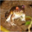

In [6]:
X_train[0]

In [7]:
y_train = y_train.reshape(-1,)
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

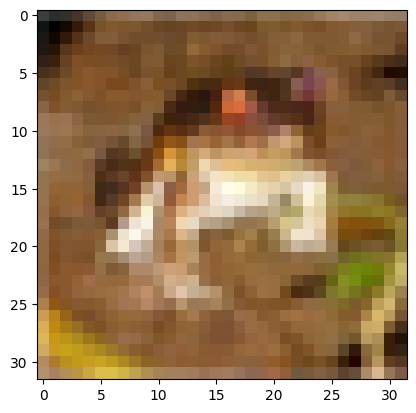

In [8]:
plt.imshow(X_train[0])

In [9]:
classes = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

In [10]:
def plot_sample(X, y, index):
    plt.figure(figsize = (15,2))
    plt.imshow(X[index])
    plt.xlabel(classes[y[index]])

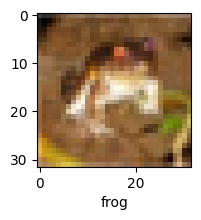

In [11]:
plot_sample(X_train, y_train, 0)

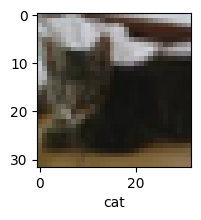

In [12]:
plot_sample(X_train, y_train, 9)

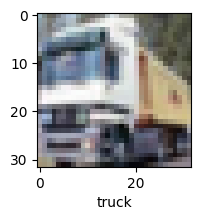

In [13]:
plot_sample(X_train, y_train, 1)

Normalize the data

In [14]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [18]:
X_train

array([[[[0.23137255, 0.24313725, 0.24705882],
         [0.16862745, 0.18039216, 0.17647059],
         [0.19607843, 0.18823529, 0.16862745],
         ...,
         [0.61960784, 0.51764706, 0.42352941],
         [0.59607843, 0.49019608, 0.4       ],
         [0.58039216, 0.48627451, 0.40392157]],

        [[0.0627451 , 0.07843137, 0.07843137],
         [0.        , 0.        , 0.        ],
         [0.07058824, 0.03137255, 0.        ],
         ...,
         [0.48235294, 0.34509804, 0.21568627],
         [0.46666667, 0.3254902 , 0.19607843],
         [0.47843137, 0.34117647, 0.22352941]],

        [[0.09803922, 0.09411765, 0.08235294],
         [0.0627451 , 0.02745098, 0.        ],
         [0.19215686, 0.10588235, 0.03137255],
         ...,
         [0.4627451 , 0.32941176, 0.19607843],
         [0.47058824, 0.32941176, 0.19607843],
         [0.42745098, 0.28627451, 0.16470588]],

        ...,

        [[0.81568627, 0.66666667, 0.37647059],
         [0.78823529, 0.6       , 0.13333333]

first building simple NN

In [24]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(32,32,3)),
    keras.layers.Dense(3000, activation='relu'),
    keras.layers.Dense(1000, activation='relu'),
    keras.layers.Dense(10, activation='sigmoid')
])

model.compile(optimizer='SGD',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X_train, y_train, epochs=5)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 142s 91ms/step - accuracy: 0.3549 - loss: 1.8110
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 131s 84ms/step - accuracy: 0.4274 - loss: 1.6225
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 145s 86ms/step - accuracy: 0.4550 - loss: 1.5401
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 139s 84ms/step - accuracy: 0.4781 - loss: 1.4808
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 150s 89ms/step - accuracy: 0.4942 - loss: 1.4333


In [25]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.4141 - loss: 1.6542


[1.6542437076568604, 0.4140999913215637]

In [29]:
from sklearn.metrics import confusion_matrix , classification_report
import numpy as np
y_pred = model.predict(X_test)
y_pred_classes = [np.argmax(element) for element in y_pred]

print("Classification Report: \n", classification_report(y_test, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step
Classification Report: 
               precision    recall  f1-score   support

           0       0.42      0.66      0.52      1000
           1       0.29      0.90      0.44      1000
           2       0.43      0.21      0.28      1000
           3       0.37      0.29      0.33      1000
           4       0.37      0.51      0.43      1000
           5       0.51      0.23      0.32      1000
           6       0.58      0.36      0.45      1000
           7       0.77      0.29      0.43      1000
           8       0.60      0.49      0.54      1000
           9       0.51      0.18      0.27      1000

    accuracy                           0.41     10000
   macro avg       0.48      0.41      0.40     10000
weighted avg       0.48      0.41      0.40     10000



In [32]:
cnn = models.Sequential([
    # cnn
    layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    # dense
    keras.layers.Flatten(),
    keras.layers.Dense(1000, activation='relu'),
    keras.layers.Dense(10, activation='sigmoid')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [33]:
cnn.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [34]:
cnn.fit(X_train, y_train, epochs=10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 108s 68ms/step - accuracy: 0.5161 - loss: 1.3457
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 140s 67ms/step - accuracy: 0.6567 - loss: 0.9759
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 142s 67ms/step - accuracy: 0.7285 - loss: 0.7809
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 107s 68ms/step - accuracy: 0.7921 - loss: 0.5989
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 106s 68ms/step - accuracy: 0.8479 - loss: 0.4361
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 142s 68ms/step - accuracy: 0.9049 - loss: 0.2795
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 106s 68ms/step - accuracy: 0.9368 - loss: 0.1836
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 105s 67ms/step - accuracy: 0.9565 - loss: 0.1283
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 142s 67ms/step - accuracy: 0.9627 - loss: 0.1087
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 106s 68ms/step - accuracy: 0.9680 - loss: 0.0902


In [ ]:
Explain Normalize and one hot encoding

1: 0.45
2: 0.67

1: (0.45) / (0.45 + 0.67) = 0.33

In [ ]:
(0.45) / (0.45 + 0.67)

In [ ]:
(0.67) / (0.45 + 0.67)

softmax will nomalize the probabily, kernel_size is filter size

In [35]:
y_test = y_test.reshape(-1,) # now it is one dimensional
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

In [ ]:

plot_sample(X_test, y_test, 1)

In [ ]:
y_pred = cnn.predict(X_test)
y_pred[:1]

In [36]:
np.argmax(y_pred[1])

np.int64(1)

In [37]:
y_classes = [np.argmax(element) for element in y_pred]
y_classes[:5]

[np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(4)]

In [38]:
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

In [39]:
print("Classification Report: \n", classification_report(y_test, y_classes))

Classification Report: 
               precision    recall  f1-score   support

           0       0.42      0.66      0.52      1000
           1       0.29      0.90      0.44      1000
           2       0.43      0.21      0.28      1000
           3       0.37      0.29      0.33      1000
           4       0.37      0.51      0.43      1000
           5       0.51      0.23      0.32      1000
           6       0.58      0.36      0.45      1000
           7       0.77      0.29      0.43      1000
           8       0.60      0.49      0.54      1000
           9       0.51      0.18      0.27      1000

    accuracy                           0.41     10000
   macro avg       0.48      0.41      0.40     10000
weighted avg       0.48      0.41      0.40     10000

